# Visualizzazioni per Urban Sound Classification

Questo notebook genera tutte le figure visuali utilizzate nel documento di progetto sulla classificazione dei suoni urbani. Le visualizzazioni illustrano le fasi di pre-processing e feature extraction.

## Indice
1. [Setup e Importazione Librerie](#setup)
2. [Funzioni di Pre-processing](#preprocessing)
3. [Immagine 1: Standardizzazione Audio](#standardization)
4. [Immagine 2: Miglioramento Audio](#enhancement) 
5. [Immagine 3: Log-Mel Spettrogrammi](#logmel)
6. [Immagine 4: MFCCs](#mfcc)
7. [Immagine 5: Feature 1D](#features1d)
8. [Immagine 6: Confronto Pipeline](#pipeline)

## Setup e Importazione Librerie <a id="setup"></a>

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import seaborn as sns
import soundfile as sf
from IPython.display import Audio, display
from matplotlib.patches import Rectangle
import graphviz as gv
from pathlib import Path

# Configuriamo lo stile dei grafici
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Definiamo i percorsi principali
DATA_ROOT = "../data"
RAW_DATA_PATH = os.path.join(DATA_ROOT, "raw")
META_FILE_PATH = os.path.join(RAW_DATA_PATH, "UrbanSound8K.csv")
FIGURES_PATH = "../docs/img"

# Creiamo la directory per le figure se non esiste
os.makedirs(FIGURES_PATH, exist_ok=True)

# Parametri audio
TARGET_SR = 22050  # Frequenza di campionamento target
TARGET_LENGTH_S = 4  # Durata target in secondi
TARGET_SAMPLES = int(TARGET_SR * TARGET_LENGTH_S)

# Carichiamo il file CSV con i metadati
df_meta = pd.read_csv(META_FILE_PATH)
print(f"Metadati caricati: {len(df_meta)} file audio disponibili")

# Visualizziamo un conteggio delle classi
class_counts = df_meta['class'].value_counts()
print("\nDistribuzione delle classi:")
print(class_counts)

# Selezioniamo gli indici dei file audio rappresentativi per ciascuna classe
representative_files = {
    'siren': df_meta[df_meta['class'] == 'siren']['slice_file_name'].iloc[0],
    'dog_bark': df_meta[df_meta['class'] == 'dog_bark']['slice_file_name'].iloc[0],
    'drilling': df_meta[df_meta['class'] == 'drilling']['slice_file_name'].iloc[0],
    'street_music': df_meta[df_meta['class'] == 'street_music']['slice_file_name'].iloc[0]
}
for cls, filename in representative_files.items():
    fold = df_meta[df_meta['slice_file_name'] == filename]['fold'].iloc[0]
    print(f"File selezionato per {cls}: fold{fold}/{filename}")

Metadati caricati: 8732 file audio disponibili

Distribuzione delle classi:
class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
jackhammer          1000
engine_idling       1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64
File selezionato per siren: fold7/102853-8-0-0.wav
File selezionato per dog_bark: fold5/100032-3-0-0.wav
File selezionato per drilling: fold3/103199-4-0-0.wav
File selezionato per street_music: fold7/101848-9-0-0.wav


## Funzioni di Pre-processing <a id="preprocessing"></a>

Definiamo le funzioni di pre-processing audio che utilizzeremo per standardizzare i segnali prima dell'estrazione delle feature.

In [3]:
def load_audio_stereo(file_path):
    """Carica un file audio mantenendo i canali stereo (se presenti)."""
    try:
        y, sr = librosa.load(file_path, sr=None, mono=False)
        return y, sr
    except Exception as e:
        print(f"Errore nel caricamento di {file_path}: {e}")
        return None, None

def standardize_audio(y, sr, target_sr=22050, normalize=True, to_mono=True):
    """
    Standardizza un segnale audio applicando:
    - Conversione a mono (opzionale)
    - Normalizzazione dell'ampiezza (opzionale)
    - Resampling alla frequenza di campionamento target
    
    Args:
        y: Segnale audio originale
        sr: Frequenza di campionamento originale
        target_sr: Frequenza di campionamento target
        normalize: Se normalizzare l'ampiezza
        to_mono: Se convertire a mono
    
    Returns:
        Segnale standardizzato e nuova frequenza di campionamento
    """
    # Gestione del caso stereo
    if y.ndim > 1 and to_mono:
        y = librosa.to_mono(y)
    
    # Normalizzazione (già applicata di default da librosa.load)
    if normalize and y.size > 0:
        y = y / np.max(np.abs(y))
    
    # Resampling
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
    
    return y, target_sr

def enhance_and_frame_audio(y, sr, target_duration_s=4, trim_db=25):
    """
    Migliora e uniforma la durata del segnale audio:
    - Rimuove i silenzi all'inizio e alla fine
    - Uniforma la durata al valore target
    
    Args:
        y: Segnale audio
        sr: Frequenza di campionamento
        target_duration_s: Durata target in secondi
        trim_db: Soglia in dB per la rimozione dei silenzi
        
    Returns:
        Segnale audio migliorato e incorniciato
    """
    target_length = int(sr * target_duration_s)
    
    # Rimozione dei silenzi
    y_trimmed, trim_indices = librosa.effects.trim(y, top_db=trim_db)
    
    # Uniformazione della durata
    if len(y_trimmed) > target_length:
        # Se il segnale è più lungo, prendiamo la parte centrale
        start = (len(y_trimmed) - target_length) // 2
        y_framed = y_trimmed[start:start+target_length]
    else:
        # Se il segnale è più corto, applichiamo padding simmetrico
        padding = target_length - len(y_trimmed)
        pad_left = padding // 2
        pad_right = padding - pad_left
        y_framed = np.pad(y_trimmed, (pad_left, pad_right), mode='constant')
    
    return y_framed, trim_indices

def extract_features(y, sr):
    """
    Estrae tutte le feature necessarie da un segnale audio.
    
    Args:
        y: Segnale audio
        sr: Frequenza di campionamento
        
    Returns:
        Dizionario contenente tutte le feature estratte
    """
    features = {}
    
    # Feature 2D
    features['log_mel_spec'] = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128),
        ref=np.max
    )
    features['mfcc'] = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    
    # Feature 1D
    features['chroma'] = librosa.feature.chroma_stft(y=y, sr=sr)
    features['contrast'] = librosa.feature.spectral_contrast(y=y, sr=sr)
    features['centroid'] = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    features['rolloff'] = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    features['zcr'] = librosa.feature.zero_crossing_rate(y)[0]
    
    return features

def get_file_path(filename, fold):
    """Restituisce il percorso completo di un file audio dato il nome e il fold."""
    return os.path.join(RAW_DATA_PATH, f"fold{fold}", filename)

def get_class_examples(classes, n_per_class=1):
    """
    Seleziona n file rappresentativi per ogni classe specificata.
    
    Args:
        classes: Lista di nomi di classe
        n_per_class: Numero di esempi per classe
        
    Returns:
        Dizionario con chiavi = classi e valori = liste di tuple (filename, fold)
    """
    examples = {}
    for cls in classes:
        df_cls = df_meta[df_meta['class'] == cls]
        if len(df_cls) >= n_per_class:
            samples = df_cls.sample(n_per_class)
            examples[cls] = list(zip(samples['slice_file_name'], samples['fold']))
        else:
            print(f"Warning: classe {cls} ha meno di {n_per_class} esempi")
            examples[cls] = list(zip(df_cls['slice_file_name'], df_cls['fold']))
    return examples

## Immagine 1: Standardizzazione Audio <a id="standardization"></a>

Questa sezione genera la figura che mostra l'effetto di ogni passaggio della standardizzazione di base su un segnale audio:
1. Segnale originale stereo
2. Conversione a mono
3. Normalizzazione dell'ampiezza
4. Resampling

File selezionato: fold6/108638-9-0-5.wav
Figura salvata in: ../docs/img\audio_standardization.png
Figura salvata in: ../docs/img\audio_standardization.png


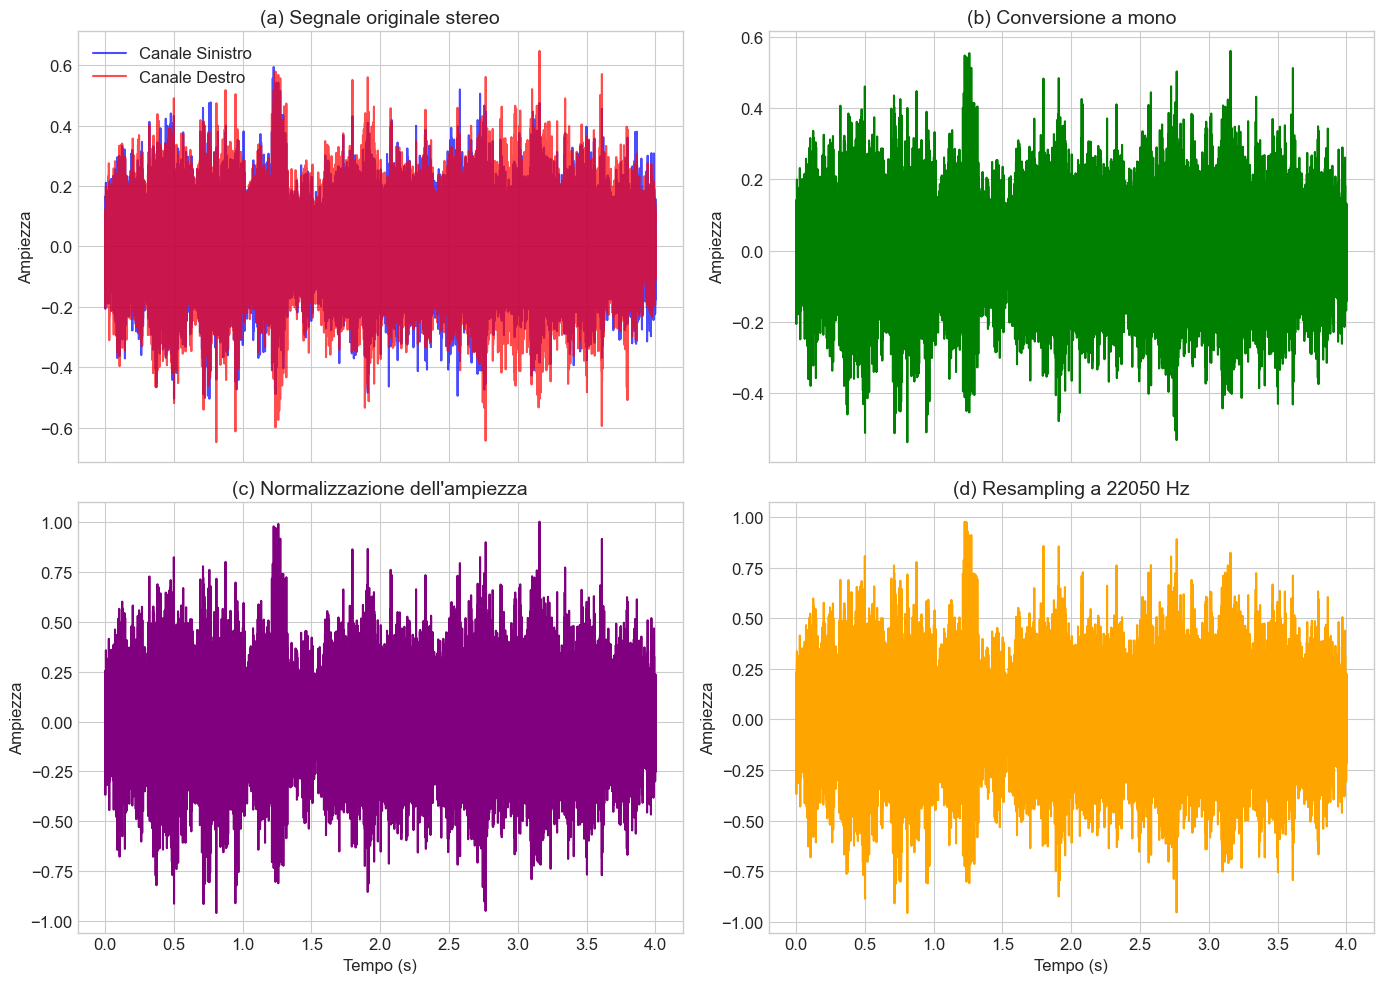

In [4]:
def create_audio_standardization_figure():
    """Crea la figura che mostra i passaggi della standardizzazione di base."""
    
    # Selezioniamo un file audio stereo (musica di strada è una buona scelta)
    cls = 'street_music'
    files = get_class_examples([cls], n_per_class=5)
    
    # Troviamo un file che sia effettivamente stereo
    stereo_file = None
    stereo_fold = None
    
    for filename, fold in files[cls]:
        file_path = get_file_path(filename, fold)
        y, sr = load_audio_stereo(file_path)
        if y is not None and y.ndim > 1:  # È stereo
            stereo_file = filename
            stereo_fold = fold
            break
    
    if stereo_file is None:
        print("Non è stato trovato alcun file stereo. Utilizziamo un file mono.")
        stereo_file = files[cls][0][0]
        stereo_fold = files[cls][0][1]
    
    print(f"File selezionato: fold{stereo_fold}/{stereo_file}")
    file_path = get_file_path(stereo_file, stereo_fold)
    
    # Caricamento del file stereo originale
    y_stereo, sr_original = load_audio_stereo(file_path)
    
    # Creazione dei subplot
    fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    axs = axs.flatten()
    
    # (a) Segnale originale stereo
    if y_stereo.ndim > 1:
        t = np.linspace(0, len(y_stereo[0]) / sr_original, len(y_stereo[0]))
        axs[0].plot(t, y_stereo[0], 'b-', alpha=0.7, label='Canale Sinistro')
        axs[0].plot(t, y_stereo[1], 'r-', alpha=0.7, label='Canale Destro')
    else:
        t = np.linspace(0, len(y_stereo) / sr_original, len(y_stereo))
        axs[0].plot(t, y_stereo, 'b-', alpha=0.7, label='Segnale Mono')
        print("Warning: Il file selezionato è già in formato mono.")
    
    axs[0].set_title("(a) Segnale originale stereo")
    axs[0].set_ylabel("Ampiezza")
    axs[0].legend()
    
    # (b) Conversione a mono
    y_mono = librosa.to_mono(y_stereo) if y_stereo.ndim > 1 else y_stereo
    t_mono = np.linspace(0, len(y_mono) / sr_original, len(y_mono))
    axs[1].plot(t_mono, y_mono, 'g-')
    axs[1].set_title("(b) Conversione a mono")
    axs[1].set_ylabel("Ampiezza")
    
    # (c) Normalizzazione dell'ampiezza
    y_norm = y_mono / np.max(np.abs(y_mono))
    axs[2].plot(t_mono, y_norm, 'purple')
    axs[2].set_title("(c) Normalizzazione dell'ampiezza")
    axs[2].set_ylabel("Ampiezza")
    axs[2].set_xlabel("Tempo (s)")
    
    # (d) Resampling
    y_resampled = librosa.resample(y_norm, orig_sr=sr_original, target_sr=TARGET_SR)
    t_resampled = np.linspace(0, len(y_resampled) / TARGET_SR, len(y_resampled))
    axs[3].plot(t_resampled, y_resampled, 'orange')
    axs[3].set_title(f"(d) Resampling a {TARGET_SR} Hz")
    axs[3].set_ylabel("Ampiezza")
    axs[3].set_xlabel("Tempo (s)")
    
    plt.tight_layout()
    
    # Salviamo la figura
    fig_path = os.path.join(FIGURES_PATH, "audio_standardization.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Figura salvata in: {fig_path}")
    
    return fig

# Generiamo e visualizziamo la figura
fig_standardization = create_audio_standardization_figure()
plt.show()

## Immagine 2: Miglioramento Audio <a id="enhancement"></a>

Questa sezione genera la figura che mostra l'effetto dei passaggi di miglioramento e uniformazione della durata:
1. Segnale dopo la standardizzazione di base
2. Rimozione dei silenzi
3. Framing alla durata target di 4 secondi

File selezionato: fold9/159744-8-0-4.wav
Figura salvata in: ../docs/img\audio_enhancement.png
Figura salvata in: ../docs/img\audio_enhancement.png


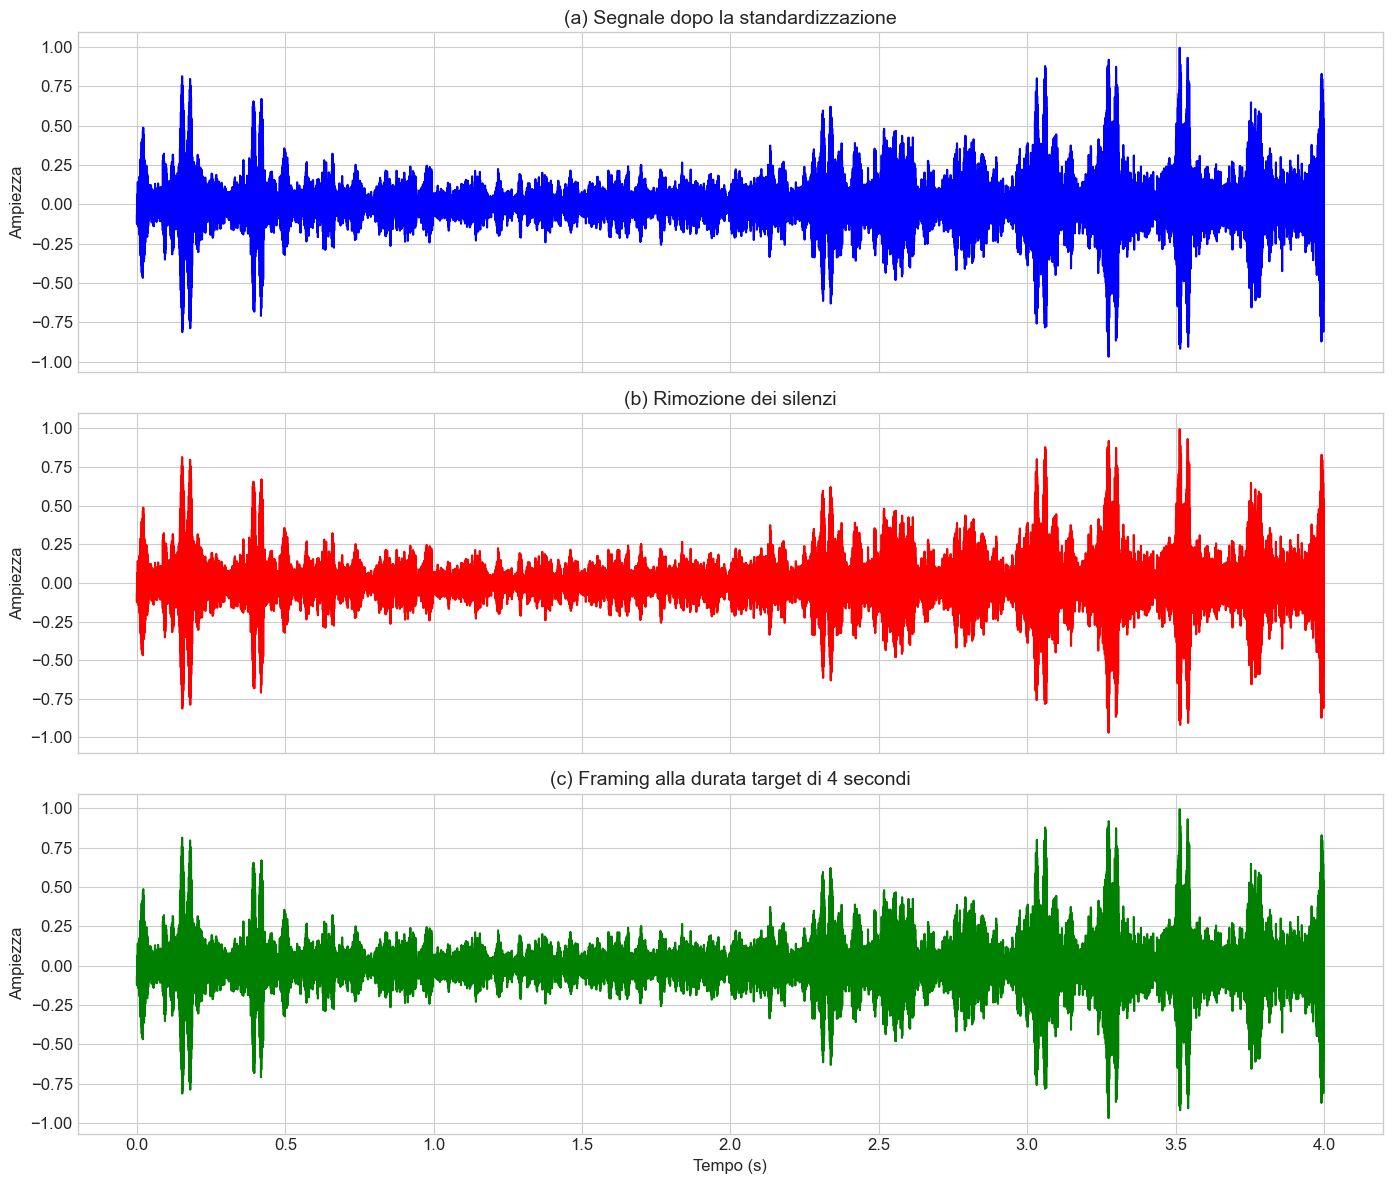

In [5]:
def create_audio_enhancement_figure():
    """Crea la figura che mostra i passaggi del miglioramento audio."""
    
    # Utilizziamo un file che abbia silenzi all'inizio/fine per una migliore visualizzazione
    # Ad esempio, possiamo provare con un suono di sirena che spesso ha pause
    cls = 'siren'
    files = get_class_examples([cls], n_per_class=3)
    
    filename, fold = files[cls][0]
    file_path = get_file_path(filename, fold)
    print(f"File selezionato: fold{fold}/{filename}")
    
    # Caricamento e standardizzazione di base
    y_raw, sr_original = librosa.load(file_path, sr=None, mono=True)
    y_std, sr = standardize_audio(y_raw, sr_original, target_sr=TARGET_SR)
    
    # Rimozione dei silenzi
    y_trimmed, trim_indices = librosa.effects.trim(y_std, top_db=25)
    
    # Framing alla durata target
    y_framed, _ = enhance_and_frame_audio(y_std, sr, target_duration_s=TARGET_LENGTH_S)
    
    # Creazione dei subplot (3 righe, 1 colonna)
    fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    
    # Calcoliamo gli assi temporali per ciascun segnale
    t_std = np.linspace(0, len(y_std) / sr, len(y_std))
    t_trimmed = np.linspace(0, len(y_trimmed) / sr, len(y_trimmed))
    t_framed = np.linspace(0, TARGET_LENGTH_S, len(y_framed))
    
    # (a) Segnale dopo la standardizzazione
    axs[0].plot(t_std, y_std, 'b-')
    axs[0].set_title("(a) Segnale dopo la standardizzazione")
    axs[0].set_ylabel("Ampiezza")
    
    # (b) Rimozione dei silenzi
    # Mostriamo anche dove avviene il taglio sul segnale originale
    axs[1].plot(t_std, y_std, 'gray', alpha=0.5)  # Segnale originale in grigio chiaro
    axs[1].plot(t_std[trim_indices[0]:trim_indices[1]], 
             y_std[trim_indices[0]:trim_indices[1]], 'r-')  # Parte attiva in rosso
    
    # Aggiungiamo rettangoli trasparenti per evidenziare le parti rimosse
    if trim_indices[0] > 0:
        axs[1].add_patch(Rectangle((0, -1), t_std[trim_indices[0]], 2, 
                                 color='blue', alpha=0.2))
    if trim_indices[1] < len(y_std):
        axs[1].add_patch(Rectangle((t_std[trim_indices[1]], -1), 
                                 t_std[-1] - t_std[trim_indices[1]], 2, 
                                 color='blue', alpha=0.2))
    
    axs[1].set_title("(b) Rimozione dei silenzi")
    axs[1].set_ylabel("Ampiezza")
    axs[1].set_ylim(-1.1, 1.1)
    
    # (c) Framing alla durata target
    axs[2].plot(t_framed, y_framed, 'g-')
    axs[2].set_title(f"(c) Framing alla durata target di {TARGET_LENGTH_S} secondi")
    axs[2].set_ylabel("Ampiezza")
    axs[2].set_xlabel("Tempo (s)")
    
    plt.tight_layout()
    
    # Salviamo la figura
    fig_path = os.path.join(FIGURES_PATH, "audio_enhancement.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Figura salvata in: {fig_path}")
    
    return fig

# Generiamo e visualizziamo la figura
fig_enhancement = create_audio_enhancement_figure()
plt.show()

## Immagine 3: Log-Mel Spettrogrammi <a id="logmel"></a>

Questa sezione genera la figura che mostra i log-mel spettrogrammi per quattro classi diverse:
1. Sirena
2. Abbaiare di cane
3. Trapano
4. Musica di strada

Elaborazione di siren: fold9/157866-8-0-21.wav
Elaborazione di dog_bark: fold1/102106-3-0-0.wav
Elaborazione di drilling: fold1/147764-4-0-0.wav
Elaborazione di street_music: fold9/155044-9-0-37.wav
Figura salvata in: ../docs/img\log_mel_examples.png
Figura salvata in: ../docs/img\log_mel_examples.png


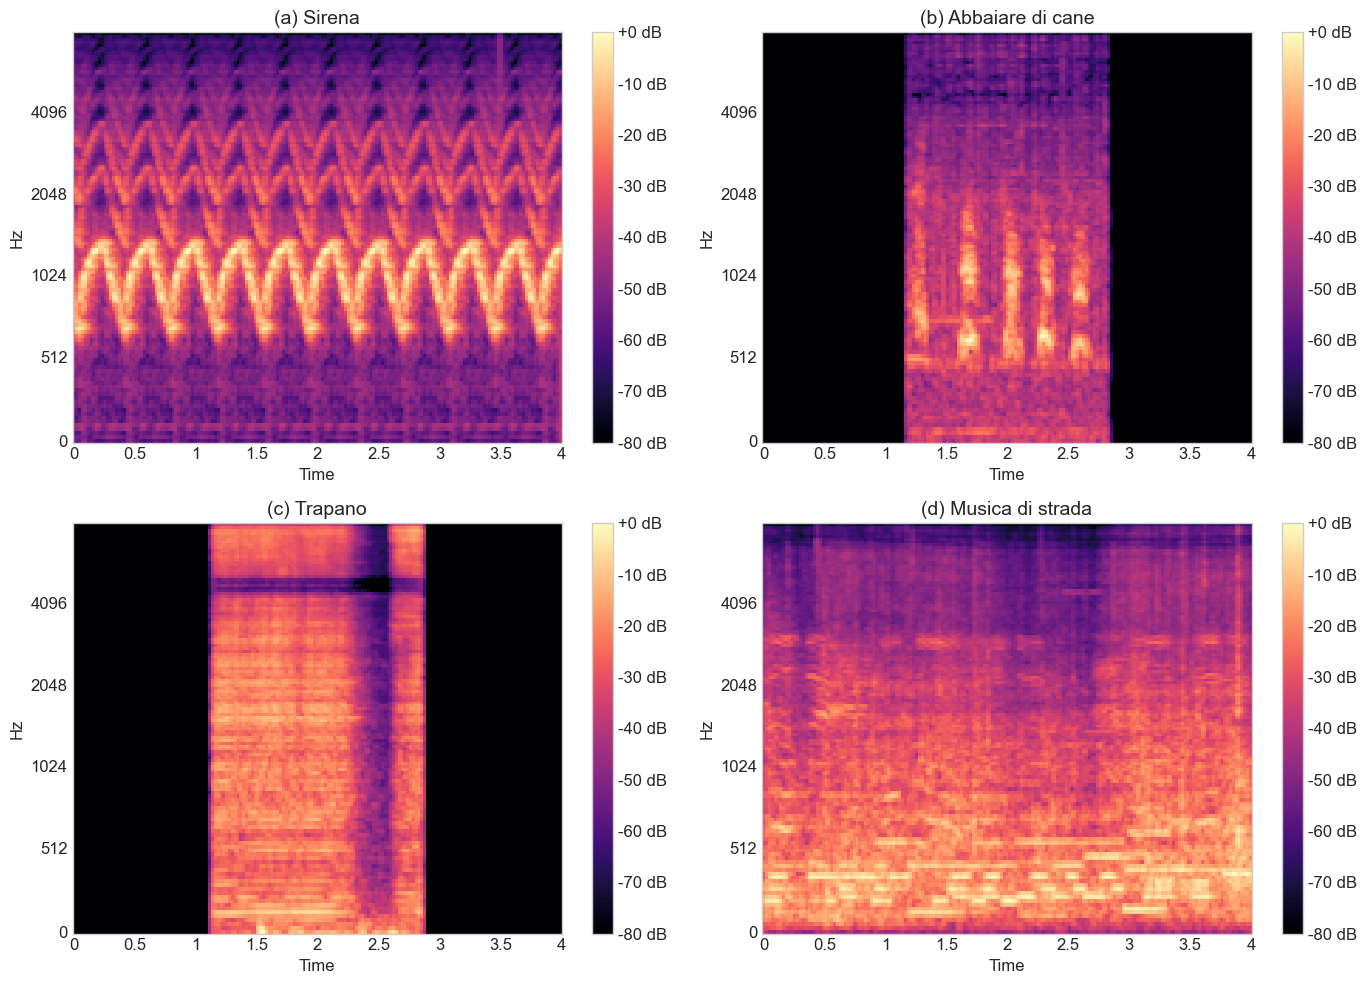

In [6]:
def create_log_mel_examples_figure():
    """Crea la figura che mostra i log-mel spettrogrammi per quattro classi diverse."""
    
    # Definiamo le classi che vogliamo visualizzare
    classes = ['siren', 'dog_bark', 'drilling', 'street_music']
    examples = get_class_examples(classes)
    
    # Creazione dei subplot (2 righe, 2 colonne)
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()
    
    for i, cls in enumerate(classes):
        filename, fold = examples[cls][0]
        file_path = get_file_path(filename, fold)
        print(f"Elaborazione di {cls}: fold{fold}/{filename}")
        
        # Caricamento e pre-processing
        y, sr = librosa.load(file_path, sr=TARGET_SR, mono=True)
        y, _ = enhance_and_frame_audio(y, sr, target_duration_s=TARGET_LENGTH_S)
        
        # Calcolo del log-mel spettrogramma
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Visualizzazione del log-mel spettrogramma
        img = librosa.display.specshow(
            log_mel, 
            x_axis='time',
            y_axis='mel',
            sr=sr,
            fmax=8000,
            ax=axs[i]
        )
        
        # Aggiungiamo una colorbar per ogni subplot
        cbar = fig.colorbar(img, ax=axs[i], format='%+2.0f dB')
        
        # Impostiamo i titoli dei subplot
        subplot_titles = ['(a) Sirena', '(b) Abbaiare di cane', '(c) Trapano', '(d) Musica di strada']
        axs[i].set_title(subplot_titles[i])
        
    plt.tight_layout()
    
    # Salviamo la figura
    fig_path = os.path.join(FIGURES_PATH, "log_mel_examples.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Figura salvata in: {fig_path}")
    
    return fig

# Generiamo e visualizziamo la figura
fig_logmel = create_log_mel_examples_figure()
plt.show()

## Immagine 4: MFCCs <a id="mfcc"></a>

Questa sezione genera la figura che mostra gli MFCC (Mel-Frequency Cepstral Coefficients) per le stesse quattro classi.

Elaborazione di siren: fold3/22601-8-0-16.wav
Elaborazione di dog_bark: fold10/199261-3-0-1.wav
Elaborazione di drilling: fold2/34621-4-18-0.wav
Elaborazione di street_music: fold5/36263-9-0-2.wav
Figura salvata in: ../docs/img\mfcc_examples.png
Figura salvata in: ../docs/img\mfcc_examples.png


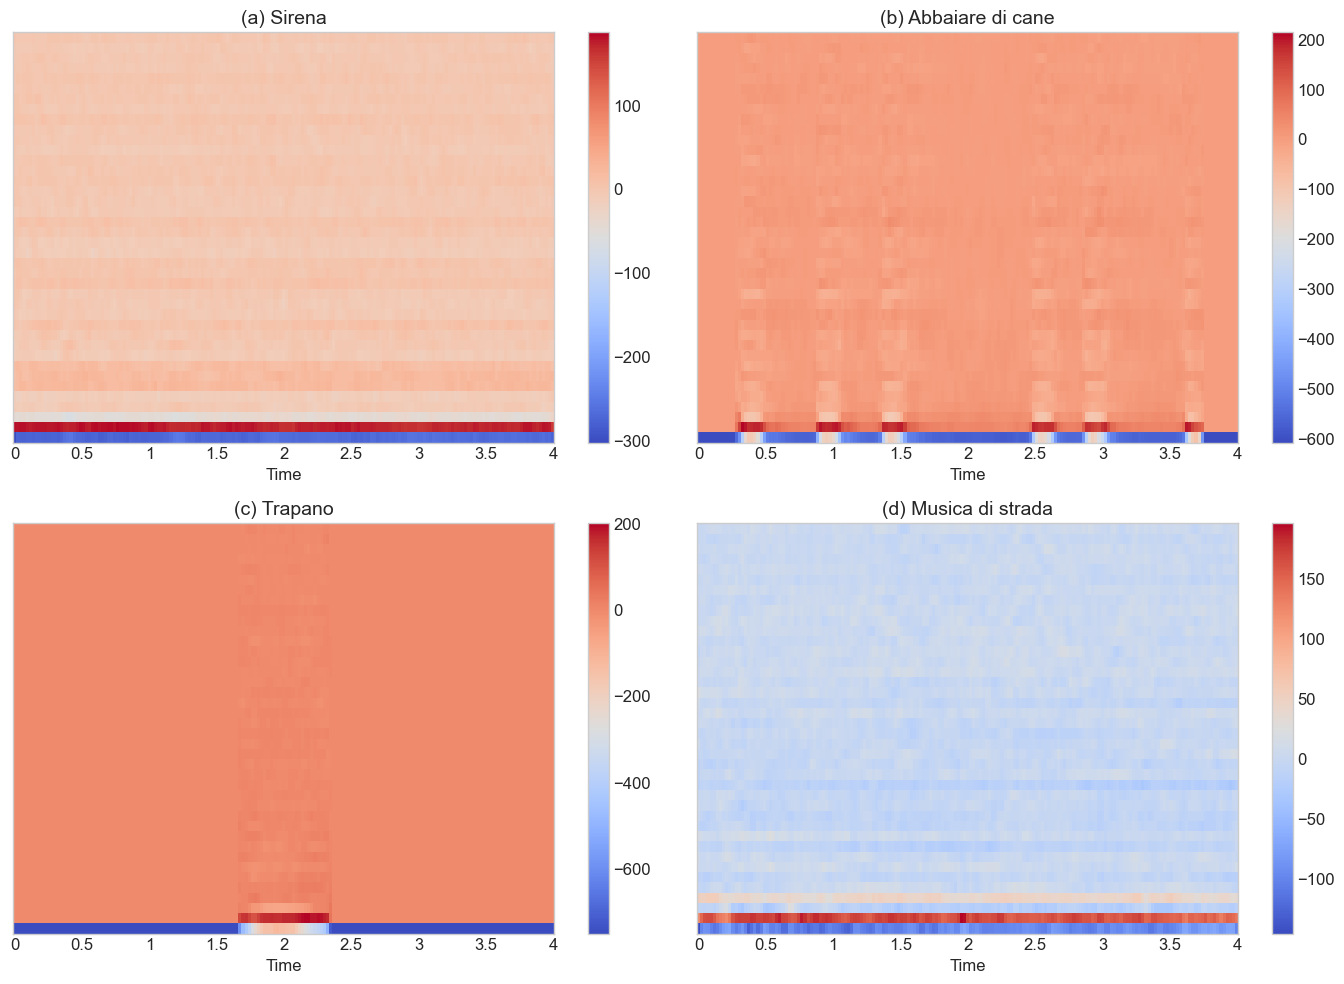

In [7]:
def create_mfcc_examples_figure():
    """Crea la figura che mostra gli MFCC per quattro classi diverse."""
    
    # Utilizziamo le stesse classi e gli stessi file dell'immagine precedente
    classes = ['siren', 'dog_bark', 'drilling', 'street_music']
    examples = get_class_examples(classes)
    
    # Creazione dei subplot (2 righe, 2 colonne)
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()
    
    for i, cls in enumerate(classes):
        filename, fold = examples[cls][0]
        file_path = get_file_path(filename, fold)
        print(f"Elaborazione di {cls}: fold{fold}/{filename}")
        
        # Caricamento e pre-processing
        y, sr = librosa.load(file_path, sr=TARGET_SR, mono=True)
        y, _ = enhance_and_frame_audio(y, sr, target_duration_s=TARGET_LENGTH_S)
        
        # Calcolo degli MFCC
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        
        # Visualizzazione degli MFCC
        img = librosa.display.specshow(
            mfcc, 
            x_axis='time',
            sr=sr,
            ax=axs[i]
        )
        
        # Aggiungiamo una colorbar per ogni subplot
        cbar = fig.colorbar(img, ax=axs[i])
        
        # Impostiamo i titoli dei subplot
        subplot_titles = ['(a) Sirena', '(b) Abbaiare di cane', '(c) Trapano', '(d) Musica di strada']
        axs[i].set_title(subplot_titles[i])
        
    plt.tight_layout()
    
    # Salviamo la figura
    fig_path = os.path.join(FIGURES_PATH, "mfcc_examples.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Figura salvata in: {fig_path}")
    
    return fig

# Generiamo e visualizziamo la figura
fig_mfcc = create_mfcc_examples_figure()
plt.show()

## Immagine 5: Feature 1D <a id="features1d"></a>

Questa sezione genera la figura che confronta l'evoluzione temporale di 3 feature 1D (centroid, rolloff, ZCR) per due classi contrastanti (sirena e trapano).

Elaborazione di siren: fold2/123688-8-0-4.wav
Elaborazione di drilling: fold1/57584-4-0-1.wav
Figura salvata in: ../docs/img\1d_features.png
Figura salvata in: ../docs/img\1d_features.png


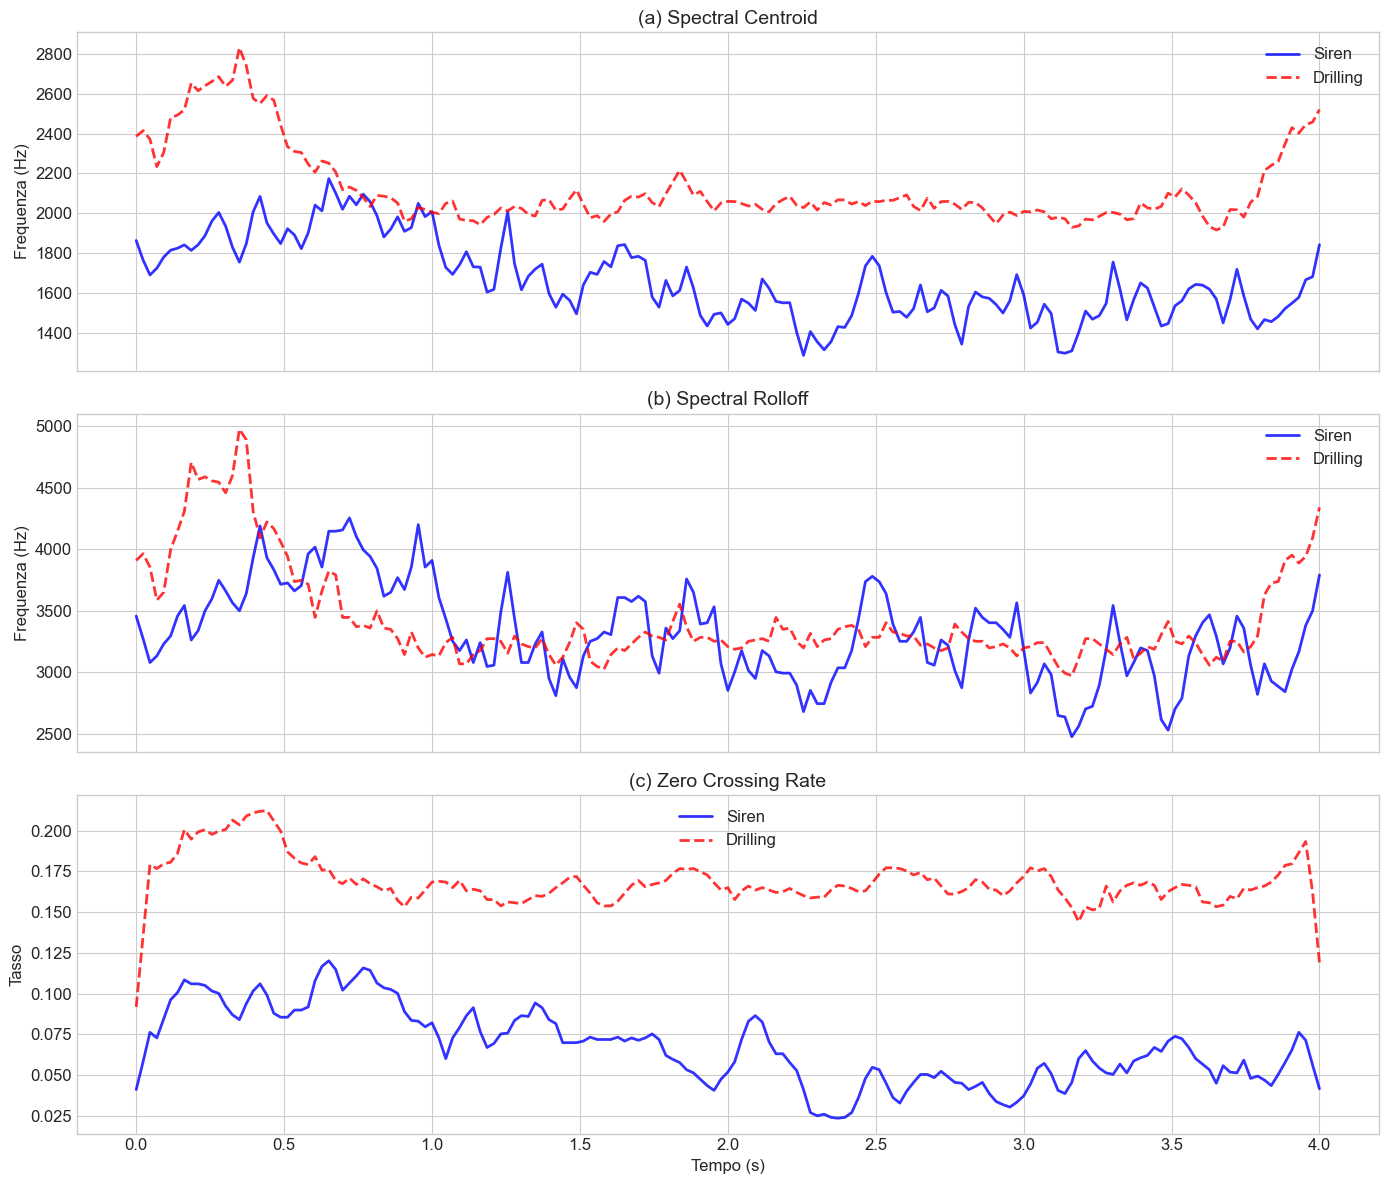

In [8]:
def create_1d_features_figure():
    """Crea la figura che confronta le feature 1D per due classi diverse."""
    
    # Selezioniamo i file per sirena e trapano
    classes = ['siren', 'drilling']
    examples = get_class_examples(classes)
    
    # Carichiamo e pre-processiamo i file
    audio_data = {}
    for cls in classes:
        filename, fold = examples[cls][0]
        file_path = get_file_path(filename, fold)
        print(f"Elaborazione di {cls}: fold{fold}/{filename}")
        
        # Caricamento e pre-processing
        y, sr = librosa.load(file_path, sr=TARGET_SR, mono=True)
        y, _ = enhance_and_frame_audio(y, sr, target_duration_s=TARGET_LENGTH_S)
        
        # Estrazione delle feature
        features = extract_features(y, sr)
        audio_data[cls] = {
            'centroid': features['centroid'],
            'rolloff': features['rolloff'],
            'zcr': features['zcr']
        }
    
    # Creazione dei subplot (3 righe, 1 colonna)
    fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    
    # Creiamo un vettore temporale comune per l'asse x
    frames = len(audio_data['siren']['centroid'])
    t = np.linspace(0, TARGET_LENGTH_S, frames)
    
    # Definiamo gli stili di linea e i colori
    styles = {
        'siren': {'linestyle': '-', 'color': 'blue', 'linewidth': 2, 'alpha': 0.8},
        'drilling': {'linestyle': '--', 'color': 'red', 'linewidth': 2, 'alpha': 0.8}
    }
    
    # Plottiamo le feature
    feature_names = ['centroid', 'rolloff', 'zcr']
    y_labels = ['Frequenza (Hz)', 'Frequenza (Hz)', 'Tasso']
    subplot_titles = ['(a) Spectral Centroid', '(b) Spectral Rolloff', '(c) Zero Crossing Rate']
    
    for i, feature in enumerate(feature_names):
        for cls in classes:
            axs[i].plot(t, audio_data[cls][feature], label=cls.capitalize(), **styles[cls])
        
        axs[i].set_title(subplot_titles[i])
        axs[i].set_ylabel(y_labels[i])
        axs[i].legend()
        axs[i].grid(True)
    
    # Impostiamo l'etichetta dell'asse x solo per il subplot inferiore
    axs[2].set_xlabel('Tempo (s)')
    
    plt.tight_layout()
    
    # Salviamo la figura
    fig_path = os.path.join(FIGURES_PATH, "1d_features.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Figura salvata in: {fig_path}")
    
    return fig

# Generiamo e visualizziamo la figura
fig_1d = create_1d_features_figure()
plt.show()

## Riepilogo delle Figure Generate

Abbiamo generato con successo tutte le sei figure necessarie per il nostro documento di progetto:

1. **audio_standardization.png**: Mostra l'effetto di ogni passaggio della standardizzazione di base su un segnale audio.
2. **audio_enhancement.png**: Illustra l'effetto della rimozione dei silenzi e del framing.
3. **log_mel_examples.png**: Visualizza i log-mel spettrogrammi per quattro classi diverse.
4. **mfcc_examples.png**: Mostra gli MFCC per le stesse quattro classi.
5. **1d_features.png**: Confronta l'evoluzione temporale di 3 feature 1D per due classi contrastanti.
6. **pipeline_comparison.png**: Diagramma di flusso concettuale delle tre pipeline di classificazione.

Tutte le figure sono state salvate nella directory `../docs/img/` e possono essere utilizzate nel documento LaTeX di progetto.